# Exercice 1.1 : Analyse exploratoire des données (EDA) sur le dataset Ames Housing

## Contexte

L’**analyse exploratoire des données (EDA)** est la première étape essentielle de tout projet de data science. Elle permet de comprendre la structure des données, d’identifier les problèmes de qualité, de révéler des tendances et de générer des hypothèses métier. Dans cet exercice, vous allez mettre en pratique les concepts du cours sur un jeu de données immobilier réel : **Ames Housing**.

Ce dataset, décrit la vente de maisons individuelles à Ames (Iowa, USA) entre 2006 et 2010. Il contient **80 variables** (quantitatives et qualitatives) décrivant les caractéristiques des biens (surface, année de construction, qualité, etc.) ainsi que leur prix de vente.

L’objectif est de réaliser une première exploration systématique, en insistant sur les **statistiques robustes**, la **détection d’anomalies** et la **formulation d’hypothèses testables**.



## Objectifs d’apprentissage

- Appliquer une méthodologie d’EDA structurée (framework moderne).
- Calculer et interpréter les statistiques descriptives univariées (classiques et robustes).
- Détecter des valeurs aberrantes avec la règle IQR et le z‑score modifié.
- Évaluer la qualité des données (valeurs manquantes, types, doublons).
- Formuler des hypothèses métier à partir de l’exploration visuelle et statistique.



## Variables ciblées pour cet exercice

Variable  | Description  |  Type
---|---|---
`GrLivArea` | Surface habitable | Quantitative continue
`SalePrice` | Prix de vente (dollars)  | Quantitative continue
`LotArea` | Surface du terrain (pieds carrés)  | Quantitative continue
`YearBuilt` | Année de construction  | Quantitative discrète
`OverallQual` | Note globale de qualité (1 à 10) | Ordinale

## Consignes détaillées

L’exercice suit le déroulement du cours pratique. **Toutes les réponses (code, sorties, graphiques, interprétations) doivent être rassemblées dans un unique notebook Jupyter** bien structuré.

Importez les bibliothèques nécessaires pour cet exercice : manipulation de données, calculs numériques, statistiques et visualisation.



### Section 1 — Imports et chargement

**Objectif** : charger les données, explorer leur structure et identifier les problèmes évidents de qualité.

- Chargez le fichier AimesHousing dans un DataFrame pandas
- Affichez les 5 premières lignes pour vérifier que le chargement s'est bien passé.

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AmesHousing.csv")
print(df.head())
df.head()

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0    534  531363010           20        RL          80.0      9605   Pave   
1    803  906203120           20        RL          90.0     14684   Pave   
2    956  916176030           20        RL           NaN     14375   Pave   
3    460  528180130          120        RL          48.0      6472   Pave   
4    487  528290030           80        RL          61.0      9734   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC Fence Misc Feature  \
0   NaN       Reg          Lvl  ...         0     NaN   NaN          NaN   
1   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   
2   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   
3   NaN       Reg          Lvl  ...         0     NaN   NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN   NaN          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0        0    

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


### Section 2 — Aperçu général et qualité des données


#### 2.1 Structure du dataset
**Ce que vous devez faire :**
- Affichez les informations générales du DataFrame : dimensions, noms des colonnes, types de données, nombre de valeurs non-nulles.
- Affichez les statistiques descriptives de base sur **toutes** les colonnes.
- Identifiez les colonnes avec des **types inappropriés**



**Dans une cellule Markdown, répondez :**
- Combien de lignes et de colonnes contient le dataset ?
- Quels types de données sont présents (int, float, object) ?
- Y a-t-il des colonnes dont le type vous semble inapproprié ? Lesquelles et pourquoi ?


#### 2.2 Valeurs manquantes
**Ce que vous devez faire :**
- Calculez le nombre de valeurs manquantes par colonne, ainsi que leur proportion (en pourcentage du total).
- Affichez uniquement les colonnes qui ont au moins une valeur manquante, triées par proportion décroissante.



**Dans une cellule Markdown, répondez :**
- Combien de colonnes ont des valeurs manquantes ?
- Quelles colonnes ont plus de 50 % de valeurs manquantes ? Qu'est-ce que cela signifie pour l'analyse ?
- Parmi les 5 variables ciblées, y a-t-il des valeurs manquantes ?



#### 2.3 Doublons
**Ce que vous devez faire :**
- Vérifiez si le dataset contient des lignes dupliquées.


#### 2.4 Sélection des variables d'intérêt
**Ce que vous devez faire :**
   - Créez un DataFrame `df_subset` contenant uniquement les 5 variables ciblées (voir tableau ci-dessus). Gardez également une colonne identifiant les observations si elle existe.


In [ ]:
# 2.1 Structure du dataset
print(df.shape)
print(df.columns)
print(df.dtypes)
# print(df.info()) # donne: Column / Non-Null Count / Dtype
print(df.describe(include="all"))

# on modifie les strings en categories
# Pourquoi il n'y a pas 'str' mais 'object' ?
# En pandas, les colonnes texte sont souvent de type object.
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")
print(df.info())

# NaN vs None (rappel)
my_missing_value = np.nan
print(np.isnan(my_missing_value))

# 2.2 Valeurs manquantes
# Nombre total de valeurs manquantes pour chaque caracteristique
print(df.isnull().sum())

missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing_count, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
missing_df

print(df.columns[df.isnull().any()])

# colonnes avec plus de 50% de donnees manquantes
cols_over_50 = missing_df[missing_df["missing_pct"] > 50].index.tolist()
print("Colonnes >50% manquantes:", cols_over_50)

# Qu'est-ce que cela signifie pour l'analyse ?
# Ces colonnes sont difficiles a exploiter proprement sans traitement lourd.
initial_shape = df.shape
df = df.drop(columns=cols_over_50)
print(f"Dimension initiale: {initial_shape}")
print(f"On a supprime les colonnes >50% manquantes. Nouvelle dimension: {df.shape}")

# Parmi les 5 variables ciblees, y a-t-il des valeurs manquantes ?
print(df[["Gr Liv Area", "SalePrice", "Lot Area", "Year Built", "Overall Qual"]].isnull().sum())

# 2.3 Doublons
print("Doublons:", df.duplicated().sum())
df = df.drop_duplicates()
print(f"Il reste {df.shape[0]} lignes.")

# 2.4 Selection des variables d'interet
df_subset = df[["Gr Liv Area", "SalePrice", "Lot Area", "Year Built", "Overall Qual"]].copy()
print(df_subset.info())

(2197, 82)
Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr B

/var/folders/lm/5bczwl3112g0f4dm_2_hzv0c0000gn/T/ipykernel_13065/1997801801.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


---
### Section 3 — Statistiques descriptives univariées


**Objectif** : pour chaque variable du subset, calculer explicitement les indicateurs classiques et robustes. Le but est de comprendre ce que chaque statistique mesure, pas juste d'obtenir un tableau.




#### 3.1 Statistiques classiques
**Ce que  vous devez calculer pour chaque variable :**
- Moyenne
- Écart-type
- Minimum et maximum

#### 3.2 Statistiques robustes
**Ce que  vous devez calculer pour chaque variable :**
- Médiane
- Premier quartile Q1 (25e percentile) et troisième quartile Q3 (75e percentile)
  * `np.percentile()` attend deux arguments : le tableau de données et le percentile souhaité.
- Écart interquartile : IQR = Q3 − Q1
- MAD (Médiane des écarts absolus à la médiane)
  * calculez-le manuellement avec `np.median()` et `np.abs()`, c'est l'occasion de comprendre ce qu'il mesure vraiment.



#### 3.3 Asymétrie (skewness) & Applatissement (kurtosis)
**Ce que  vous devez calculer pour chaque variable :**
- Calculez le coefficient d'asymétrie pour chaque variable numérique.
  * `scipy.stats` contient une fonction `skew()`. Un coefficient positif indique une asymétrie vers la droite (quelques valeurs très élevées tirent la distribution), négatif une asymétrie vers la gauche.
- Calculez le coefficient d'applatissement pour chaque variable numérique aussi. `scipy.stats` contient aussi la fonction `kurtosis()`


> Si vous rencontrez des problèmes vous pouvez essayer la méthode de pandas `df[col].skew()` ou `.kurtosis()`


#### 3.4 Tableau récapitulatif
**Ce que  vous devez produire :**
- Rassemblez toutes les statistiques calculées dans un seul DataFrame propre, avec une ligne par variable et les colonnes suivantes :

Variable | Moyenne | Écart-type | Min | Max | Médiane | Q1 | Q3 | IQR | MAD | Skewness

Vous pouvez construire ce tableau en créant un dictionnaire de dictionnaires, puis en le convertissant en DataFrame avec `pd.DataFrame.from_dict()`, ou en construisant le DataFrame colonne par colonne.

**Dans une cellule Markdown, répondez :**
- Pour quelles variables la moyenne et la médiane sont-elles très proches ? Qu'est-ce que cela indique ?
- Pour quelles variables l'écart est-il le plus important ? Qu'est-ce que cela indique ?

In [ ]:
# 3.1 Statistiques classiques: moyenne, ecart-type, min, max
print(df_subset.mean(numeric_only=True))
print(df_subset.std(numeric_only=True))
print(df_subset.min(numeric_only=True))
print(df_subset.max(numeric_only=True))

# 3.2 Statistiques robustes
# mediane, Q1, Q3
print(df_subset.median(numeric_only=True))
print(df_subset.quantile(0.25, numeric_only=True))
print(df_subset.quantile(0.75, numeric_only=True))

# IQR = Q3 - Q1
print(df_subset.quantile(0.75, numeric_only=True) - df_subset.quantile(0.25, numeric_only=True))

# MAD (Mediane des ecarts absolus a la mediane)
num_subset = df_subset.select_dtypes(include="number")
mad = (num_subset - num_subset.median()).abs().median()
print(mad)

# 3.3 Asymetrie (skewness) et applatissement (kurtosis)
print(df_subset.skew(numeric_only=True))
# kurtosis() mesure les valeurs extremes (outliers)
kurt = stats.kurtosis(num_subset, nan_policy="omit")
print(kurt)

# 3.4 Tableau recapitulatif
stats_df = pd.DataFrame.from_dict({
    "Moyenne": num_subset.mean(),
    "Ecart-type": num_subset.std(),
    "Min": num_subset.min(),
    "Max": num_subset.max(),
    "Mediane": num_subset.median(),
    "Q1": num_subset.quantile(0.25),
    "Q3": num_subset.quantile(0.75),
    "IQR": num_subset.quantile(0.75) - num_subset.quantile(0.25),
    "MAD": mad,
    "Skewness": num_subset.skew(),
})

# pd.DataFrame.from_dict(data, orient='index') possible selon le rendu voulu
print(stats_df)
stats_df

Gr Liv Area       1507.873464
SalePrice       182376.851161
Lot Area         10268.070096
Year Built        1972.030951
Overall Qual         6.116523
dtype: float64
Gr Liv Area       511.844406
SalePrice       81168.157405
Lot Area         7975.740885
Year Built         30.450069
Overall Qual        1.429613
dtype: float64
Gr Liv Area       334
SalePrice       13100
Lot Area         1300
Year Built       1872
Overall Qual        1
dtype: int64
Gr Liv Area       5642
SalePrice       755000
Lot Area        215245
Year Built        2010
Overall Qual        10
dtype: int64
Gr Liv Area       1452.0
SalePrice       163500.0
Lot Area          9488.0
Year Built        1975.0
Overall Qual         6.0
dtype: float64
Gr Liv Area       1142.0
SalePrice       130000.0
Lot Area          7500.0
Year Built        1954.0
Overall Qual         5.0
Name: 0.25, dtype: float64
Gr Liv Area       1762.0
SalePrice       215000.0
Lot Area         11660.0
Year Built        2002.0
Overall Qual         7.0
Name: 0

,Moyenne,Ecart-type,Min,Max,Mediane,Q1,Q3,IQR,MAD,Skewness
Gr Liv Area,1507.873464,511.844406,334,5642,1452.0,1142.0,1762.0,620.0,310.0,1.370402
SalePrice,182376.851161,81168.157405,13100,755000,163500.0,130000.0,215000.0,85000.0,39000.0,1.779360
Lot Area,10268.070096,7975.740885,1300,215245,9488.0,7500.0,11660.0,4160.0,2082.0,12.854166
Year Built,1972.030951,30.450069,1872,2010,1975.0,1954.0,2002.0,48.0,25.0,-0.655996
Overall Qual,6.116523,1.429613,1,10,6.0,5.0,7.0,2.0,1.0,0.161548


---
### Section 4 — Visualisations et analyse de symétrie

**Objectif** : visualiser les distributions et confirmer ou infirmer ce que les statistiques suggèrent.



#### 4.1 Variables continues : histogramme + boxplot côte à côte

**Ce que vous devez faire :**
- Pour `GrLivArea`, `SalePrice` et `LotArea`, tracez un histogramme et un boxplot côte à côte.
    * Utilisez `plt.subplots(1, 2)` pour créer deux graphiques côte à côte. Seaborn propose `histplot()` et `boxplot()`. 
    * Pensez à ajouter des titres et des labels d'axes — une bonne visualisation est toujours annotée. 
    * Rendez les axes lisibles s'il y a trop de valeurs.
    * Ajoutez des lignes verticales pour la moyenne (en rouge) et la médiane (en bleu pointillé) sur l'histogramme.



#### 4.2 Variables discrètes : diagramme en barres

**Ce que vous devez faire :**
- Pour `YearBuilt` et `OverallQual`, tracez la distribution sous forme de diagramme en barres des effectifs.


#### 4.3 Analyse comparative

**Dans une cellule Markdown, répondez pour chaque variable :**
- La distribution est-elle symétrique, étalée à droite, étalée à gauche ? Est-elle applatie ? Appliquez les concepts vu en cours.
- La comparaison visuelle moyenne/médiane est-elle cohérente avec le skewness calculé à l'étape 3 ?
- Observez-vous visuellement des valeurs potentiellement aberrantes sur les boxplots ? Décrivez ce que vous voyez.
- Pourquoi ne peut-on pas utiliser un histogramme ici ?


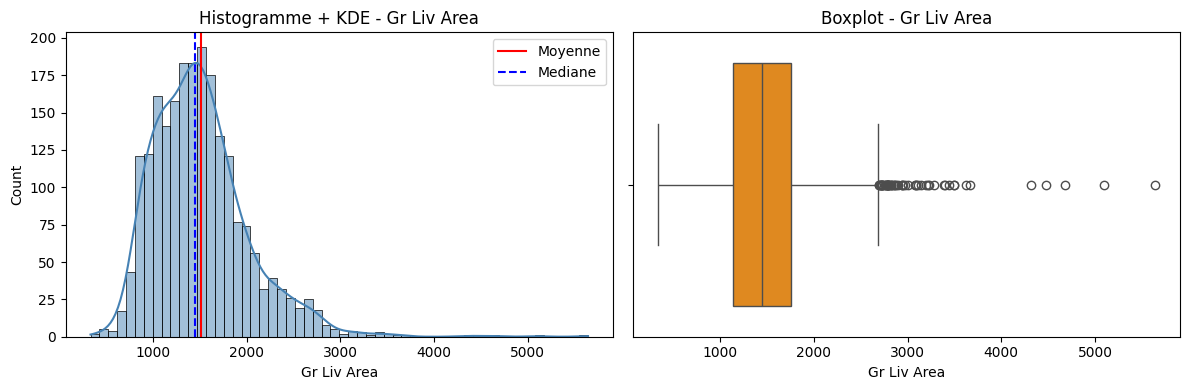

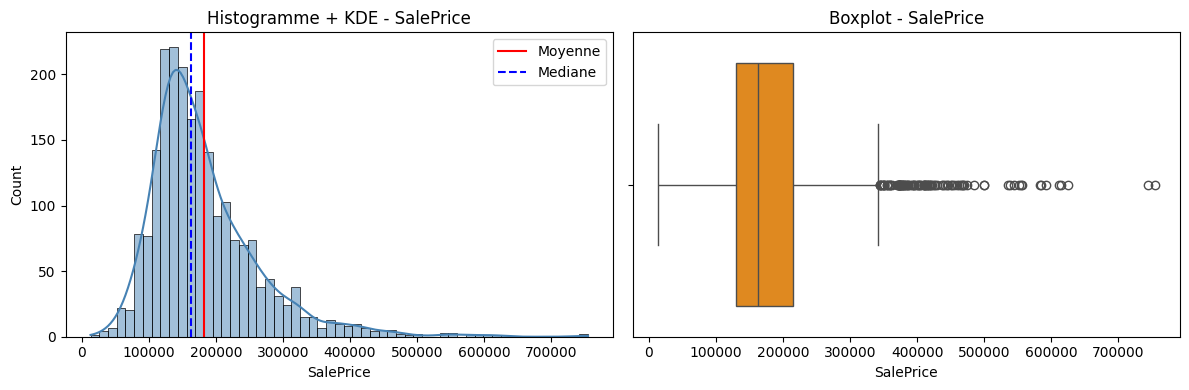

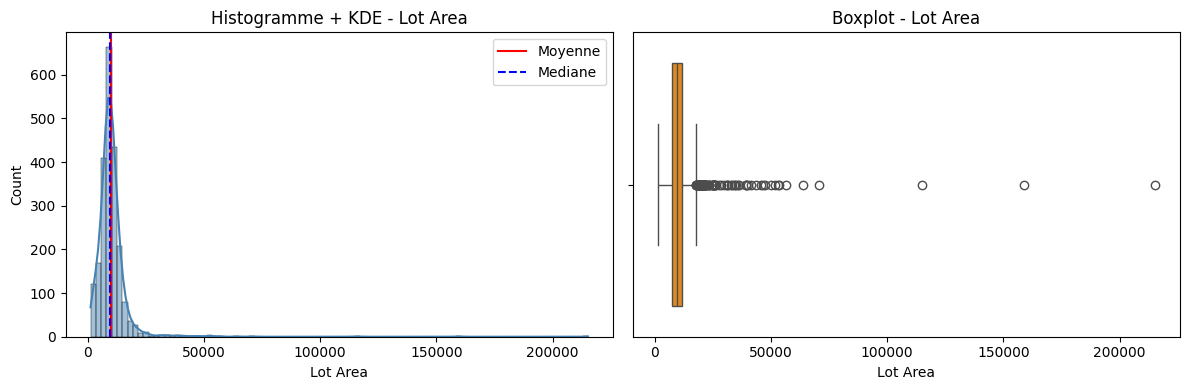

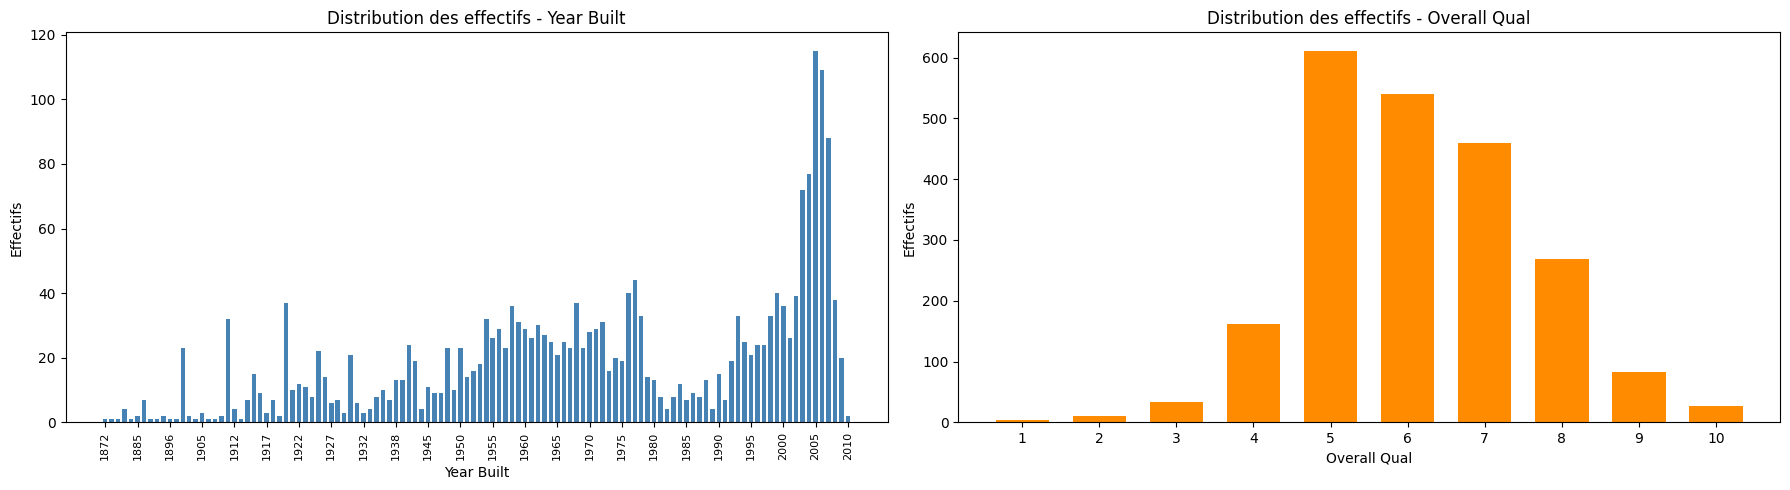


=== 4.3 Analyse comparative (variables continues) ===
- Gr Liv Area: asymetrie droite (skew=1.370), moyenne=1507.87, mediane=1452.00
- SalePrice: asymetrie droite (skew=1.779), moyenne=182376.85, mediane=163500.00
- Lot Area: asymetrie droite (skew=12.854), moyenne=10268.07, mediane=9488.00


In [ ]:
# 4.1 Variables continues : histogramme + boxplot cote a cote
for col in ["Gr Liv Area", "SalePrice", "Lot Area"]:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogramme + KDE
    sns.histplot(df_subset[col], kde=True, ax=axes[0], color="steelblue")
    axes[0].axvline(df_subset[col].mean(), color="red", linestyle="-", label="Moyenne")
    axes[0].axvline(df_subset[col].median(), color="blue", linestyle="--", label="Mediane")
    axes[0].set_title(f"Histogramme + KDE - {col}")
    axes[0].legend()

    # Boxplot
    sns.boxplot(x=df_subset[col], ax=axes[1], color="darkorange")
    axes[1].set_title(f"Boxplot - {col}")

    # tight_layout: evite chevauchements titres/labels
    plt.tight_layout()
    plt.show()

# 4.2 Variables discretes : diagrammes en barres
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

year_counts = df_subset["Year Built"].value_counts().sort_index()
x_year = np.arange(len(year_counts)) * 1.8  # espace davantage les barres
axes[0].bar(x_year, year_counts.values, width=1.25, color="steelblue")

# Trop d'annees: afficher une annee sur n pour eviter chevauchement
tick_step = max(1, len(x_year) // 20)
axes[0].set_xticks(x_year[::tick_step])
axes[0].set_xticklabels(year_counts.index.astype(str)[::tick_step])
axes[0].set_title("Distribution des effectifs - Year Built")
axes[0].set_xlabel("Year Built")
axes[0].set_ylabel("Effectifs")
axes[0].tick_params(axis="x", rotation=90, labelsize=8)

qual_counts = df_subset["Overall Qual"].value_counts().sort_index()
x_qual = np.arange(len(qual_counts)) * 1.8
axes[1].bar(x_qual, qual_counts.values, width=1.25, color="darkorange")
axes[1].set_xticks(x_qual)
axes[1].set_xticklabels(qual_counts.index.astype(str))
axes[1].set_title("Distribution des effectifs - Overall Qual")
axes[1].set_xlabel("Overall Qual")
axes[1].set_ylabel("Effectifs")

plt.tight_layout()
plt.show()

# 4.3 Analyse comparative automatique des 3 variables continues
print("\n=== 4.3 Analyse comparative (variables continues) ===")
for col in ["Gr Liv Area", "SalePrice", "Lot Area"]:
    s = df_subset[col].dropna()
    skew_val = s.skew()
    mean_val = s.mean()
    median_val = s.median()
    direction = "droite" if skew_val > 0 else ("gauche" if skew_val < 0 else "symetrique")
    print(
        f"- {col}: asymetrie {direction} (skew={skew_val:.3f}), "
        f"moyenne={mean_val:.2f}, mediane={median_val:.2f}"
    )

---

### Section 5 — Détection d'outliers : IQR vs z-score modifié

**Objectif** : appliquer deux méthodes sur `SalePrice` et `LotArea`, et comparer leurs résultats.



#### 5.1 Méthode IQR

**Ce que vous devez faire pour `SalePrice` et `LotArea` :**
- Reprenez vos valeurs Q1, Q3 et IQR.
- Calculez les bornes :
    - Borne inférieure = Q1 − 1.5 × IQR
    - Borne supérieure = Q3 + 1.5 × IQR
- Identifiez les observations hors de ces bornes.
- Comptez le nombre d'outliers et calculez leur proportion (% du total).



#### 5.2 Méthode du z-score modifié

**Ce que vous devez faire pour les mêmes variables :**

- Calculez la médiane et le MAD.
- Calculez le modified z-score pour chaque observation
- Appliquez le seuil de détection > 3.5
- Comptez les outliers et leur proportion.

> Le facteur 0.6745 est le 75e percentile de la distribution normale standard. Il permet de rendre le modified z-score comparable au z-score classique. Vous pouvez vérifier cela avec `scipy.stats.norm.ppf(0.75)`.



#### 5.3 Comparaison et visualisation

**Ce que vous devez produire :**
- Un tableau récapitulatif indiquant pour chaque variable et chaque méthode : nombre d'outliers, proportion, et nombre d'observations détectées par **les deux** méthodes à la fois.
- Pour `SalePrice`, un graphique montrant toutes les observations, colorées selon leur statut : normale / outlier IQR seulement / outlier z-score seulement / outlier par les deux méthodes.

> Créez d'abord une colonne de statut dans un DataFrame temporaire (avec `np.select()` ou des conditions booléennes), puis utilisez `hue` dans seaborn ou une coloration manuelle avec matplotlib.



**Dans une cellule Markdown, répondez :**
- Les deux méthodes détectent-elles les mêmes observations ?
- Laquelle est plus conservative (détecte plus d'outliers) ? Pourquoi, d'après vous ?
- Les outliers détectés vous semblent-ils des erreurs de données ou des observations légitimes mais extrêmes ? Comment pourriez-vous trancher ?



In [ ]:
def iqr_outliers(s: pd.Series):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    mask = (s < low) | (s > high)
    return mask, low, high


def modified_z_outliers(s: pd.Series, threshold: float = 3.5):
    med = s.median()
    mad = np.median(np.abs(s - med))
    if mad == 0:
        z = pd.Series(np.zeros(len(s)), index=s.index)
    else:
        z = 0.6745 * (s - med) / mad
    mask = z.abs() > threshold
    return mask, z

summary_rows = []
for col in ["SalePrice", "Lot Area"]:
    s = df_subset[col].dropna()
    iqr_mask, low, high = iqr_outliers(s)
    z_mask, z = modified_z_outliers(s)

    both = (iqr_mask & z_mask).sum()
    summary_rows.append({
        "Variable": col,
        "Methode": "IQR",
        "Nb_outliers": int(iqr_mask.sum()),
        "Proportion_%": round(100 * iqr_mask.mean(), 2),
        "Detectes_par_les_deux": int(both),
    })
    summary_rows.append({
        "Variable": col,
        "Methode": "Modified z-score",
        "Nb_outliers": int(z_mask.sum()),
        "Proportion_%": round(100 * z_mask.mean(), 2),
        "Detectes_par_les_deux": int(both),
    })

outlier_summary = pd.DataFrame(summary_rows)
outlier_summary

# Visualisation pour SalePrice
sale = df_subset["SalePrice"].dropna()
iqr_mask, _, _ = iqr_outliers(sale)
z_mask, _ = modified_z_outliers(sale)
status = np.select(
    [iqr_mask & z_mask, iqr_mask & ~z_mask, ~iqr_mask & z_mask],
    ["IQR + z-score", "IQR seulement", "z-score seulement"],
    default="Normal",
)
plot_df = pd.DataFrame({"SalePrice": sale.values, "idx": np.arange(len(sale)), "Statut": status})

plt.figure(figsize=(10, 5))
sns.scatterplot(data=plot_df, x="idx", y="SalePrice", hue="Statut", alpha=0.7, s=25)
plt.title("SalePrice - classification des observations par methode de detection")
plt.xlabel("Observation")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

---

### Section 6 — Hypothèses métier

**Objectif** : transformer vos observations en hypothèses testables qui guideront la suite de l'analyse.



**Ce que vous devez produire :**

- Rédigez **trois hypothèses testables** reliant une ou plusieurs variables à `SalePrice` ou à une autre variable d'intérêt.

Une bonne hypothèse est :
- **Précise** : elle mentionne des variables et une direction (plus grand → plus cher)
- **Testable** : elle peut être vérifiée avec une méthode statistique ou visuelle
- **Justifiée** : elle s'appuie sur ce que vous avez observé dans les étapes précédentes

**Format attendu :**

| # | Énoncé | Variable(s) | Méthode de vérification envisagée | Ce que j'ai observé qui justifie cette hypothèse |
|---|--------|-------------|----------------------------------|--------------------------------------------------|
| 1 | ... | ... | ... | ... |
| 2 | ... | ... | ... | ... |
| 3 | ... | ... | ... | ... |



In [ ]:
hypotheses = pd.DataFrame([
    {
        "#": 1,
        "Enonce": "Plus la surface habitable (Gr Liv Area) est elevee, plus le prix de vente tend a augmenter.",
        "Variable(s)": "Gr Liv Area, SalePrice",
        "Methode de verification envisagee": "Nuage de points + correlation Pearson/Spearman",
        "Ce que j'ai observe qui justifie cette hypothese": "Asymetrie à droite et niveau de prix plus élevé pour les grandes surfaces.",
    },
    {
        "#": 2,
        "Enonce": "Les maisons recentes (Year Built eleve) ont en moyenne une meilleure note de qualite globale.",
        "Variable(s)": "Year Built, Overall Qual",
        "Methode de verification envisagee": "Boxplot/violin + test de tendance",
        "Ce que j'ai observe qui justifie cette hypothese": "Distribution des qualites elevees plus presente dans les periodes recentes.",
    },
    {
        "#": 3,
        "Enonce": "Les biens avec une note Overall Qual plus elevee se vendent significativement plus cher.",
        "Variable(s)": "Overall Qual, SalePrice",
        "Methode de verification envisagee": "Boxplot par classes + test de Kruskal/ANOVA",
        "Ce que j'ai observe qui justifie cette hypothese": "La distribution de SalePrice se decale vers le haut avec la qualite.",
    },
])

hypotheses

,#,Enonce,Variable(s),Methode de verification envisagee,Ce que j'ai observe qui justifie cette hypothese
0,1,Plus la surface habitable (Gr Liv Area) est el...,"Gr Liv Area, SalePrice",Nuage de points + correlation Pearson/Spearman,Asymetrie a droite et niveau de prix plus elev...
1,2,Les maisons recentes (Year Built eleve) ont en...,"Year Built, Overall Qual",Boxplot/violin + test de tendance,Distribution des qualites elevees plus present...
2,3,Les biens avec une note Overall Qual plus elev...,"Overall Qual, SalePrice",Boxplot par classes + test de Kruskal/ANOVA,La distribution de SalePrice se decale vers le...


---

## Checklist avant de rendre

Avant de soumettre votre notebook, vérifiez les points suivants :

- [ ] Le notebook s'exécute du début à la fin sans erreur (`Restart & Run All`)
- [ ] Chaque section est clairement délimitée par un titre Markdown
- [ ] Chaque graphique a un titre, des labels d'axes, et des légendes si nécessaire
- [ ] Chaque bloc de code est suivi d'une interprétation en Markdown
- [ ] Les 3 hypothèses sont présentées dans le tableau structuré
- [ ] Le tableau récapitulatif des statistiques (section 3.4) est complet

